In [1]:
! pip install q kaggle
from google.colab import files
import pandas as pd
import numpy as np
from google.colab import autoviz
import seaborn as sns
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imagesoasis' dataset.
Path to dataset files: /kaggle/input/imagesoasis


In [15]:
import os

path = "/kaggle/input/imagesoasis/Data"

folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]

print("Folders present:")
for folder in folders:
    print(folder)

Folders present:
Non Demented
Very mild Dementia
Moderate Dementia
Mild Dementia


In [16]:
import os

base_path = "/kaggle/input/imagesoasis/Data"

for root, dirs, files in os.walk(base_path):
    print(f"\n📁 {root}")
    print("Subfolders:", dirs)
    print("Files count:", len(files))


📁 /kaggle/input/imagesoasis/Data
Subfolders: ['Non Demented', 'Very mild Dementia', 'Moderate Dementia', 'Mild Dementia']
Files count: 0

📁 /kaggle/input/imagesoasis/Data/Non Demented
Subfolders: []
Files count: 67222

📁 /kaggle/input/imagesoasis/Data/Very mild Dementia
Subfolders: []
Files count: 13725

📁 /kaggle/input/imagesoasis/Data/Moderate Dementia
Subfolders: []
Files count: 488

📁 /kaggle/input/imagesoasis/Data/Mild Dementia
Subfolders: []
Files count: 5002


# 🧠 Alzheimer's Disease Detection using CNN (Fast & Memory-Efficient Model)

Found 86437 files belonging to 4 classes.
Using 69150 files for training.
Found 86437 files belonging to 4 classes.
Using 17287 files for validation.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4322/4322 ━━━━━━━━━━━━━━━━━━━━ 103s 22ms/step - accuracy: 0.7844 - loss: 0.5291 - val_accuracy: 0.7830 - val_loss: 0.4653
Epoch 2/5
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 79s 18ms/step - accuracy: 0.8045 - loss: 0.4520 - val_accuracy: 0.8179 - val_loss: 0.4323
Epoch 3/5
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - accuracy: 0.8201 - loss: 0.4108 - val_accuracy: 0.8222 - val_loss: 0.4015
Epoch 4/5
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 88s 20ms/step - accuracy: 0.8341 - loss: 0.3840 - val_accuracy: 0.8456 - val_loss: 0.3703
Epoch 5/5
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 78s 18ms/step - accuracy: 0.8457 - loss: 0.3628 - val_accuracy: 0.8540 - val_loss: 0.3505


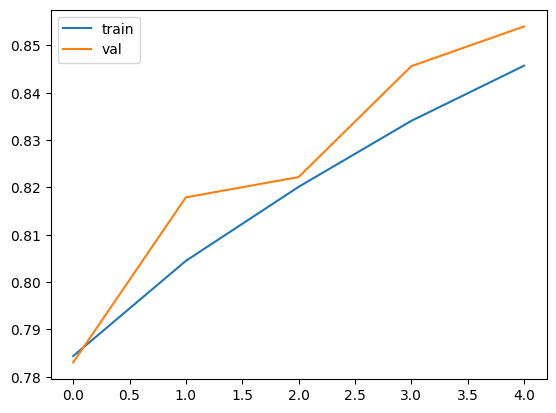

✅ TRAINED WITHOUT CRASH!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =========================
# 1. Dataset Path
# =========================
dataset_path = "/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data"

img_size = (128, 128)
batch_size = 16

# =========================
# 2. Load Dataset
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =========================
# 3. Optimize WITHOUT cache
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# =========================
# 4. Data Augmentation
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

# =========================
# 5. Build Lightweight Model
# =========================
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

# =========================
# 6. Compile
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 7. Train (SAFE)
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# =========================
# 8. Plot
# =========================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# =========================
# 9. Save
# =========================
model.save("safe_model.h5")

print("✅ TRAINED WITHOUT CRASH!")

Saving OAS1_0028_MR1_mpr-1_100 (1).jpg to OAS1_0028_MR1_mpr-1_100 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
✅ Prediction: Very mild Dementia
🔥 Confidence: 29.96%

📊 All Class Probabilities:
Mild Dementia: 29.93%
Moderate Dementia: 17.86%
Non Demented: 22.25%
Very mild Dementia: 29.96%


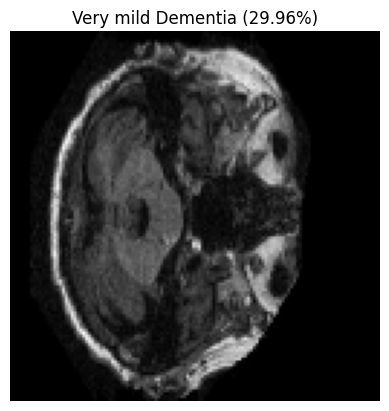

In [ ]:
# =========================
# 1. Upload Image
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# 2. Load Required Libraries
# =========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# =========================
# 3. Load Trained Model
# =========================
model = tf.keras.models.load_model("safe_model.h5")
# (change name if different)

# =========================
# 4. Class Names (IMPORTANT)
# =========================
class_names = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

# =========================
# 5. Get Uploaded Image
# =========================
img_path = list(uploaded.keys())[0]

# =========================
# 6. Preprocess Image
# =========================
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

img_array = img_array / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0)

# =========================
# 7. Predict
# =========================
predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions) * 100

# =========================
# 8. Print Results
# =========================
print("✅ Prediction:", class_names[predicted_class])
print("🔥 Confidence: {:.2f}%".format(confidence))

print("\n📊 All Class Probabilities:")
for i, prob in enumerate(predictions[0]):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# =========================
# 9. Show Image
# =========================
plt.imshow(img)
plt.title(f"{class_names[predicted_class]} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

Found 86437 files belonging to 4 classes.
Using 69150 files for training.
Found 86437 files belonging to 4 classes.
Using 17287 files for validation.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Epoch 1/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 342s 74ms/step - accuracy: 0.5921 - loss: 0.5930 - val_accuracy: 0.7190 - val_loss: 0.7012
Epoch 2/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 315s 73ms/step - accuracy: 0.7009 - loss: 0.3835 - val_accuracy: 0.7849 - val_loss: 0.5253
Epoch 3/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 323s 75ms/step - accuracy: 0.7542 - loss: 0.2912 - val_accuracy: 0.7736 - val_loss: 0.5672
Epoch 4/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 317s 73ms/step - accuracy: 0.7912 - loss: 0.2352 - val_accuracy: 0.8521 - val_loss: 0.4012
Epoch 5/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 325s 75ms/step - accuracy: 0.8246 - loss: 0.1983 - val_accuracy: 0.8897 - val_loss: 0.2927
Epoch 6/10
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 324s 75ms/step - accuracy: 0.8514 - loss: 0.1601 - val_ac

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


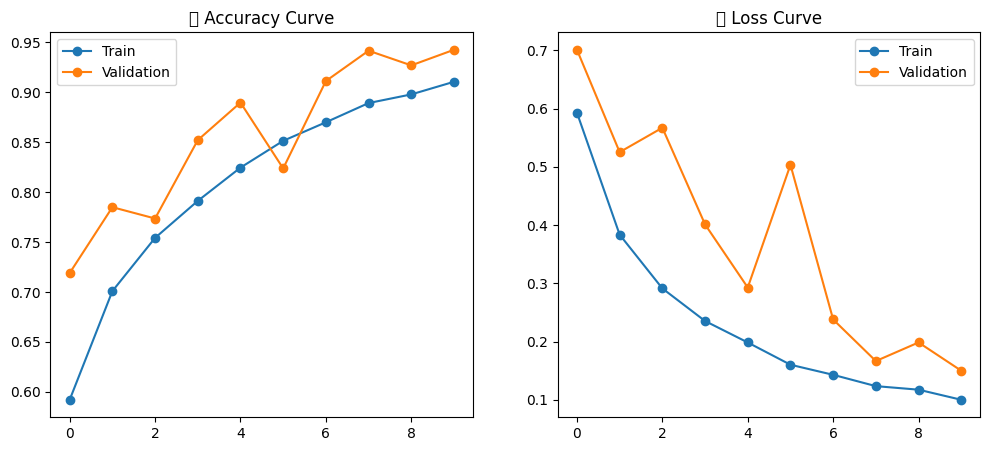

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


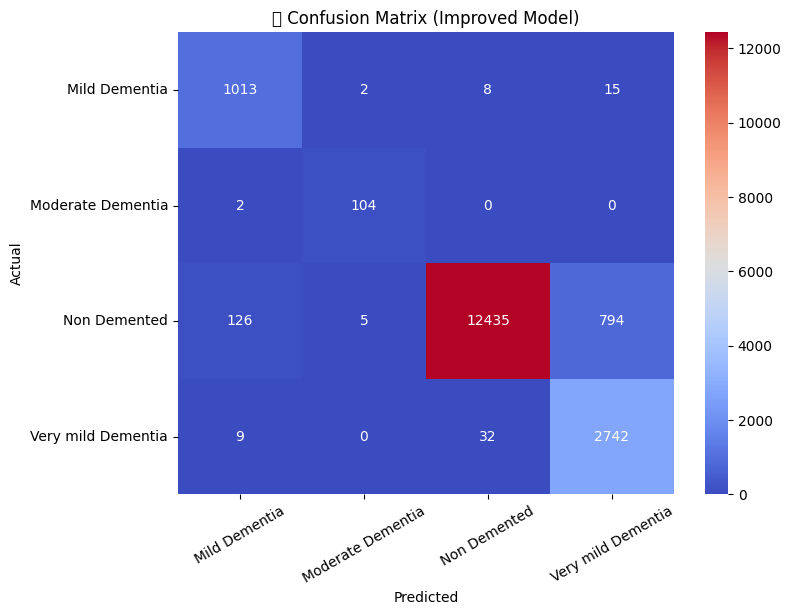

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



📄 Classification Report:

                    precision    recall  f1-score   support

     Mild Dementia       0.88      0.98      0.93      1038
 Moderate Dementia       0.94      0.98      0.96       106
      Non Demented       1.00      0.93      0.96     13360
Very mild Dementia       0.77      0.99      0.87      2783

          accuracy                           0.94     17287
         macro avg       0.90      0.97      0.93     17287
      weighted avg       0.95      0.94      0.94     17287



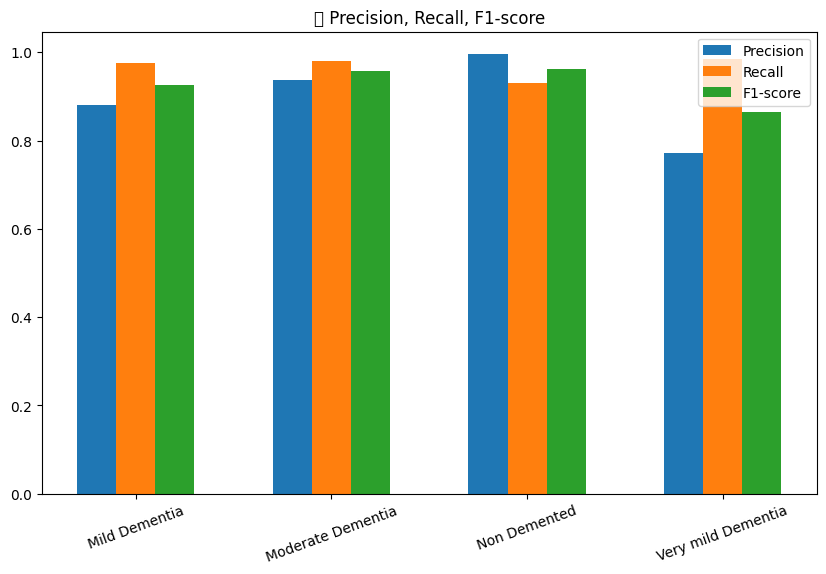

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


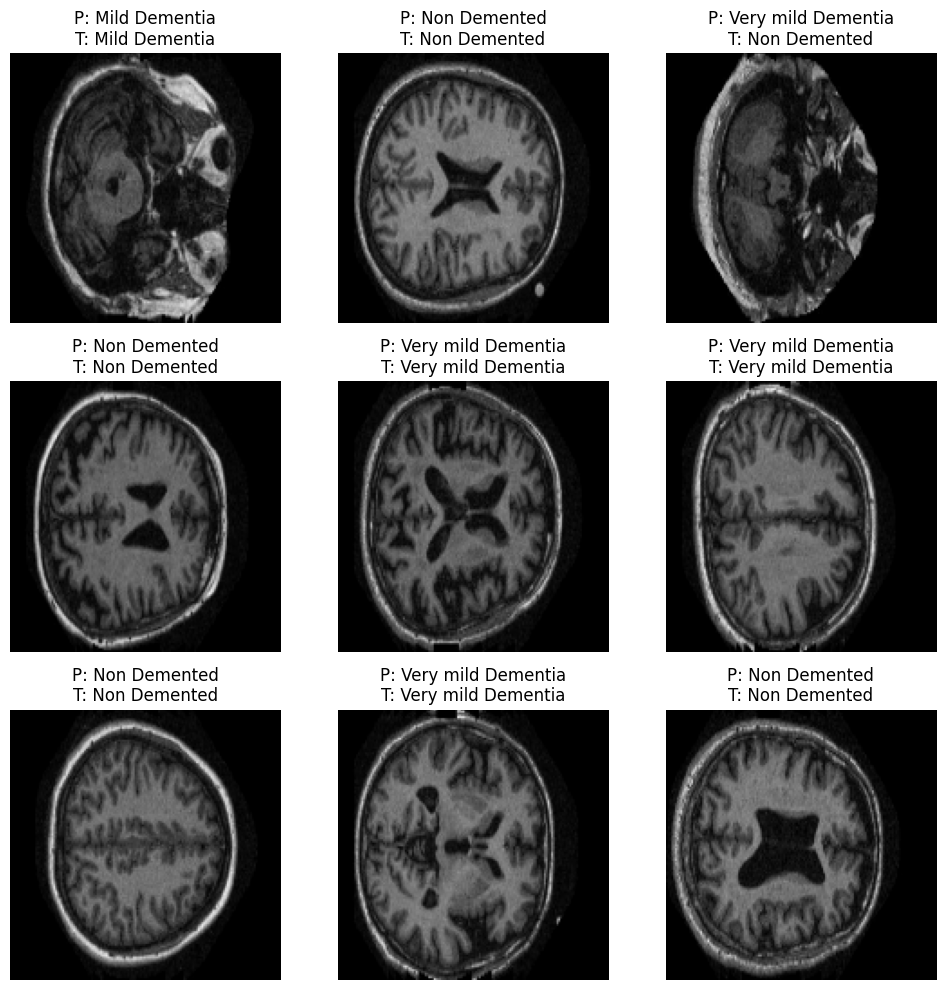

✅ FINAL IMPROVED MODEL READY 🚀


In [ ]:
# =========================
# 🧠 Alzheimer's Classification using InceptionV3 (Final Improved Model)
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# =========================
# 1. Dataset Path
# =========================
dataset_path = "/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data"

img_size = (150, 150)
batch_size = 16

# =========================
# 2. Load Dataset
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =========================
# 3. Optimize Pipeline
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# =========================
# 4. Data Augmentation
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

# =========================
# 5. Load InceptionV3
# =========================
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

# 🔥 Fine-tuning (IMPORTANT)
base_model.trainable = True
for layer in base_model.layers[:200]:
    layer.trainable = False

# =========================
# 6. Build Model
# =========================
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

# =========================
# 7. Compile
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 8. Improved Class Weights
# =========================
class_weights = {
    0: 3.0,   # Mild
    1: 8.0,   # Moderate (rare)
    2: 0.2,   # Non Demented
    3: 2.0    # Very mild
}

# =========================
# 9. Early Stopping
# =========================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =========================
# 10. Train Model
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# =========================
# 11. Accuracy & Loss Graph
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("📈 Accuracy Curve")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title("📉 Loss Curve")
plt.legend(["Train", "Validation"])

plt.show()

# =========================
# 12. Predictions
# =========================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# =========================
# 13. Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("🧠 Confusion Matrix (Improved Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30)
plt.show()

# =========================
# 14. Classification Report
# =========================
print("\n📄 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# 15. Precision / Recall / F1 Graph
# =========================
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)

x = np.arange(len(class_names))

plt.figure(figsize=(10,6))
plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')

plt.xticks(x, class_names, rotation=20)
plt.title("📊 Precision, Recall, F1-score")
plt.legend()
plt.show()

# =========================
# 16. Sample Predictions
# =========================
plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    preds = model.predict(images)

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        pred_label = class_names[np.argmax(preds[i])]
        true_label = class_names[labels[i]]

        plt.title(f"P: {pred_label}\nT: {true_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# 17. Save Model
# =========================
model.save("final_inception_finetuned.h5")

print("✅ FINAL IMPROVED MODEL READY 🚀")

Main Code


📤 Upload a Brain MRI Image



Saving OAS1_0308_MR1_mpr-1_101.jpg to OAS1_0308_MR1_mpr-1_101 (1).jpg

⏳ Loading Model...


✅ Model Loaded Successfully!

🔍 Analyzing Image...



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🧠 FINAL PREDICTION RESULT

📌 Predicted Class : Non Demented
🔥 Confidence      : 100.00%

📊 Detailed Probabilities:
--------------------------------------------------
Mild Dementia        :   0.00% | 
Moderate Dementia    :   0.00% | 
Non Demented         : 100.00% | █████████████████████████████████████████████████
Very mild Dementia   :   0.00% | 


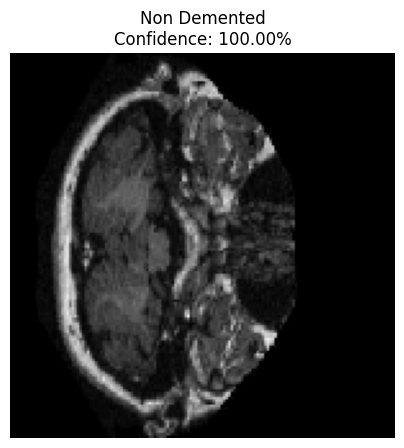

In [ ]:
# =========================
# 🧠 Alzheimer's Detection - Model Testing Interface
# =========================

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 🎯 Upload Image
# =========================
print("\n📤 Upload a Brain MRI Image\n")
uploaded = files.upload()

# =========================
# 🚀 Load Model
# =========================
print("\n⏳ Loading Model...")
model = tf.keras.models.load_model("final_inception_finetuned.h5")
print("✅ Model Loaded Successfully!\n")

# =========================
# 🏷️ Class Labels
# =========================
class_names = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

# =========================
# 🖼️ Get Image
# =========================
img_path = list(uploaded.keys())[0]

# =========================
# 🔄 Preprocess Image
# =========================
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# =========================
# 🤖 Prediction
# =========================
print("🔍 Analyzing Image...\n")
predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions) * 100

# =========================
# 🧠 Results
# ====x=====================
print("="*50)
print("🧠 FINAL PREDICTION RESULT")
print("="*50)

print(f"\n📌 Predicted Class : {class_names[predicted_class]}")
print(f"🔥 Confidence      : {confidence:.2f}%")

print("\n📊 Detailed Probabilities:")
print("-"*50)

for i, prob in enumerate(predictions[0]):
    bar = "█" * int(prob * 50)   # visual bar
    print(f"{class_names[i]:20} : {prob*100:6.2f}% | {bar}")

print("="*50)

# =========================
# 🖼️ Display Image
# =========================
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{class_names[predicted_class]}\nConfidence: {confidence:.2f}%", fontsize=12)
plt.axis("off")
plt.show()

✅ Using: inception_v3


/tmp/ipykernel_15948/222352595.py:116: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


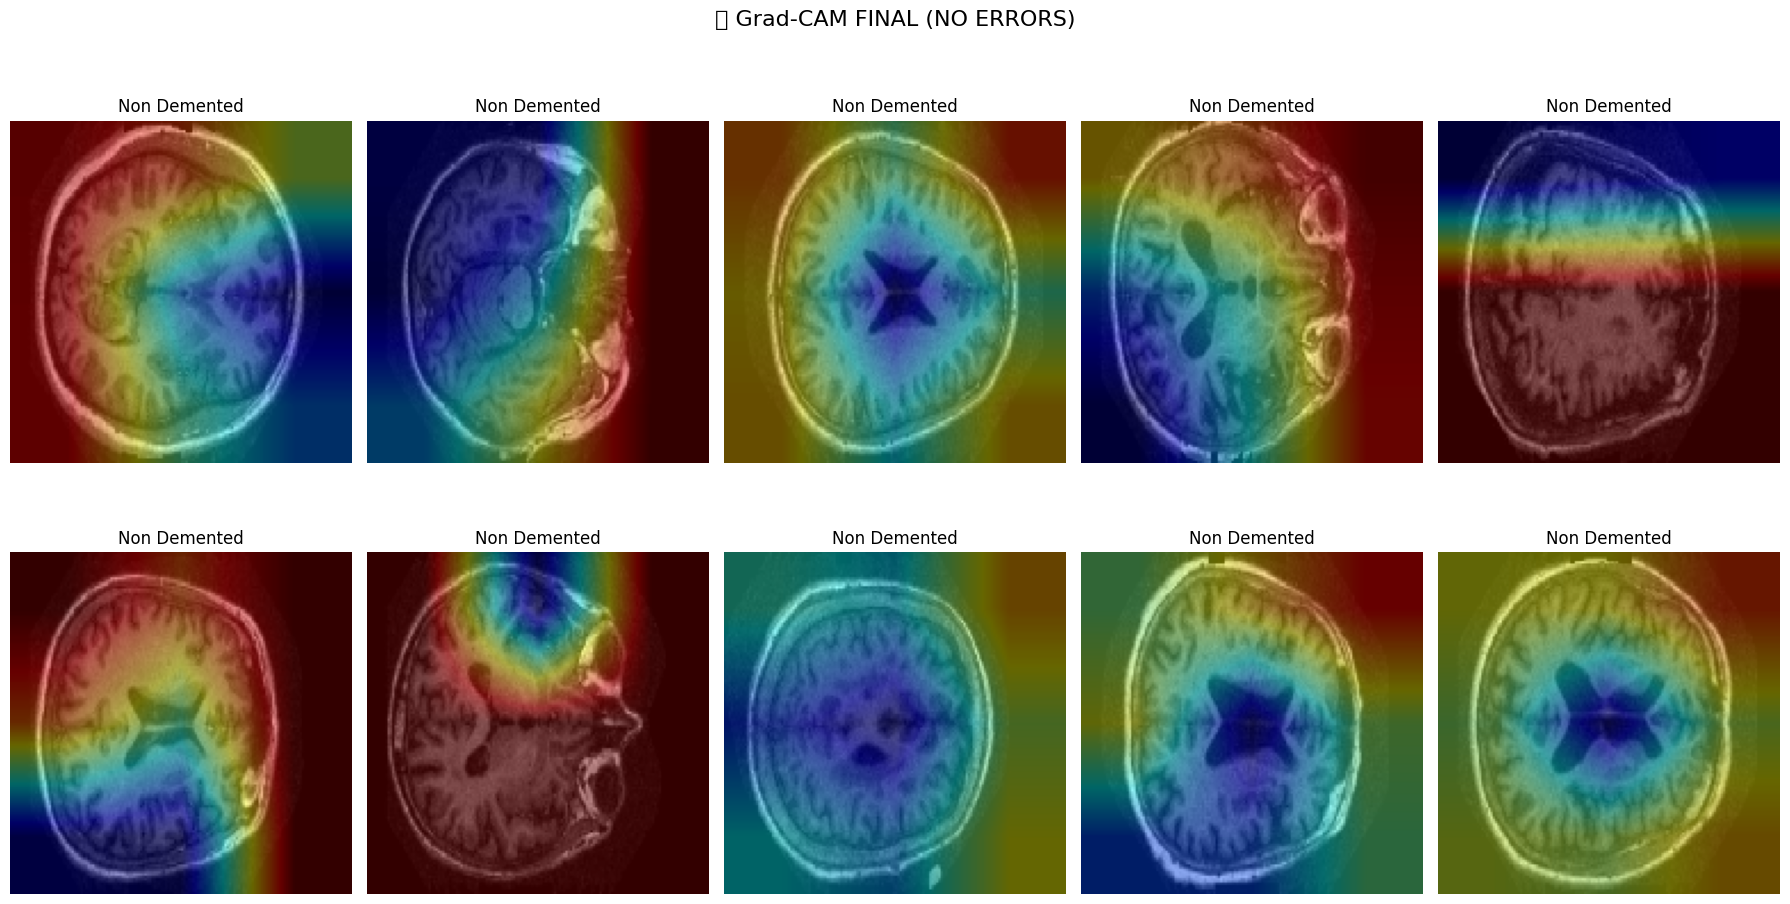

In [ ]:
# =========================
# 🧠 FINAL Grad-CAM (Bulletproof Version)
# =========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random

# =========================
# Load Model
# =========================
model = tf.keras.models.load_model("final_inception_finetuned.h5")

class_names = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

dataset_path = "/root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1/Data"

# =========================
# 🔥 Extract InceptionV3 ONLY
# =========================
base_model = None

for layer in model.layers:
    if "inception" in layer.name.lower():
        base_model = layer

print("✅ Using:", base_model.name)

# =========================
# 🔥 Extract classifier head
# =========================
# (everything after base_model)
x = base_model.output
for layer in model.layers:
    if layer.name not in base_model.name:
        try:
            x = layer(x)
        except:
            pass

classifier_model = tf.keras.Model(base_model.input, x)

# =========================
# GradCAM FUNCTION
# =========================
last_conv_layer = base_model.get_layer("mixed10")

def get_gradcam_heatmap(img_array):

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, classifier_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# =========================
# Collect Images
# =========================
image_paths = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    for img in os.listdir(class_folder):
        image_paths.append(os.path.join(class_folder, img))

sample_images = random.sample(image_paths, 10)

# =========================
# Plot
# =========================
plt.figure(figsize=(18,10))

for i, img_path in enumerate(sample_images):

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150,150))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds)

    heatmap = get_gradcam_heatmap(img_array)

    heatmap = cv2.resize(heatmap, (150,150))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = np.array(img)
    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.subplot(2,5,i+1)
    plt.imshow(superimposed)
    plt.title(class_names[pred_class])
    plt.axis("off")

plt.suptitle("🔥 Grad-CAM FINAL (NO ERRORS)", fontsize=16)
plt.tight_layout()
plt.show()

# 🧠 Alzheimer’s Classification with InceptionV3

Welcome to this **production-ready training pipeline**!  
We’ll be using **InceptionV3** (a powerful CNN pretrained on ImageNet) and adapting it for our dataset.  
Since the dataset is **highly imbalanced** (Non-Demented dominates, Moderate Dementia is rare), we’ll apply **class weighting** to ensure fair learning.

---

## 🔑 Key Highlights of the Approach

1. **Data Preparation**  
   - Organized into folders (`Data/ClassName/...`)  
   - Augmentation applied (rotation, zoom, flips) to improve generalization  
   - Train/Validation split handled via `ImageDataGenerator`

2. **Class Imbalance Handling**  
   - Used `compute_class_weight` from `sklearn`  
   - Rare classes get higher weight during training  
   - Prevents the model from being biased toward majority class

3. **Model Architecture**  
   - Base: **InceptionV3** (pretrained on ImageNet, frozen initially)  
   - Custom head: Global Average Pooling → Dense → Dropout → Softmax  
   - Fine-tuning: Unfreeze top layers later for better feature learning

4. **Training Strategy**  
   - Phase 1: Train only custom head (fast convergence, avoids overfitting)  
   - Phase 2: Fine-tune last 50 layers with smaller LR (extract deeper features)  
   - Loss: `categorical_crossentropy`  
   - Optimizer: Adam with LR scheduling

5. **Evaluation**  
   - Accuracy alone is misleading → use **classification report & confusion matrix**  
   - Monitor per-class performance (especially rare classes)

6. **Deployment Ready**  
   - Final model saved as `.h5`  
   - Can be integrated into Flask/Django apps  
   - Optional: Add **Grad-CAM visualization** for interpretability




In [18]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight

Step 2: Dataset Path

In [19]:
data_dir = "/kaggle/input/imagesoasis/Data"
img_size = (224, 224)
batch_size = 32

Step 3: Data Generators (with Augmentation)

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.


Step 4: Compute Class Weights (IMPORTANT)

In [21]:
# Get class labels
labels = train_generator.classes

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(4.319777611194403), 1: np.float64(44.21419437340153), 2: np.float64(0.3214650972516642), 3: np.float64(1.574476320582878)}


Step 5: Build InceptionV3 Model

In [22]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Step 6: Compile Model

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Step 7: Train Model (with Class Weights)

In [30]:
# Step control
steps_per_epoch = (train_generator.samples // batch_size) // 4
validation_steps = (val_generator.samples // batch_size) // 4

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps
)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 302s 559ms/step - accuracy: 0.6150 - loss: 0.9592 - val_accuracy: 0.6257 - val_loss: 0.9204
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 292s 542ms/step - accuracy: 0.6353 - loss: 0.8761 - val_accuracy: 0.6637 - val_loss: 0.8150
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 294s 546ms/step - accuracy: 0.6327 - loss: 0.9070 - val_accuracy: 0.6579 - val_loss: 0.8592
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 287s 533ms/step - accuracy: 0.6340 - loss: 0.9035 - val_accuracy: 0.6775 - val_loss: 0.7918
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.6875 - loss: 0.7343 - val_accuracy: 0.6794 - val_loss: 0.7953
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 318s 505ms/step - accuracy: 0.6483 - loss: 0.8501 - val_accuracy: 0.6389 - val_loss: 0.9082
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 272s 505ms/step - accuracy: 0.6494 - loss: 0.8657 - val_accuracy: 0.6613 - val_loss: 0.8354
Epoch 8/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 274s 508ms/step - accuracy: 0.6419 - 

In [32]:
model.save("alzheimers_inceptionv3.h5")

In [33]:
from google.colab import files
files.download("alzheimers_inceptionv3.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import numpy as np
from tensorflow.keras.models import load_model
from IPython.display import display
import ipywidgets as widgets
import io
from PIL import Image

# Load model
model = load_model("alzheimers_inceptionv3.h5")

# Class labels
class_labels = {
    0: "Mild Dementia",
    1: "Moderate Dementia",
    2: "Non Demented",
    3: "Very mild Dementia"
}

# Upload button
upload = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

# Prediction
def predict_uploaded_image(uploaded_file):
    for filename, file_info in uploaded_file.value.items():

        # ✅ FIX: convert to RGB
        img = Image.open(io.BytesIO(file_info['content'])).convert("RGB")
        img = img.resize((224, 224))

        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)[0]

        predicted_class = np.argmax(predictions)
        confidence = float(np.max(predictions))

        print("\n🧠 Prediction:")
        print(f"➡️ {class_labels[predicted_class]} ({confidence*100:.2f}%)")

        print("\n📊 All Probabilities:")
        for i, prob in enumerate(predictions):
            print(f"{class_labels[i]}: {prob*100:.2f}%")

# Trigger
def on_upload_change(change):
    if upload.value:
        predict_uploaded_image(upload)

upload.observe(on_upload_change, names='value')

FileUpload(value={}, accept='image/*', description='Upload')

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

🧠 Prediction:
➡️ Very mild Dementia (72.87%)

📊 All Probabilities:
Mild Dementia: 4.93%
Moderate Dementia: 5.52%
Non Demented: 16.68%
Very mild Dementia: 72.87%


In [ ]:
from google.colab import files
files.download("final_inception_finetuned.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>